In [ ]:
from google.colab import userdata
import os
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [ ]:
!pip install -q kaggle --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 11.8 MB/s eta 0:00:00


In [ ]:
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 276MB/s]



In [ ]:
import zipfile
with zipfile.ZipFile('creditcardfraud.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [ ]:
import pandas as pd


df = pd.read_csv('/content/creditcard.csv')


print(df.shape)
print(df['Class'].value_counts())



(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
print(df.isnull().sum().sum())

0


In [ ]:

print(df[['Amount', 'Time']].describe())

              Amount           Time
count  284807.000000  284807.000000
mean       88.349619   94813.859575
std       250.120109   47488.145955
min         0.000000       0.000000
25%         5.600000   54201.500000
50%        22.000000   84692.000000
75%        77.165000  139320.500000
max     25691.160000  172792.000000


In [ ]:
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


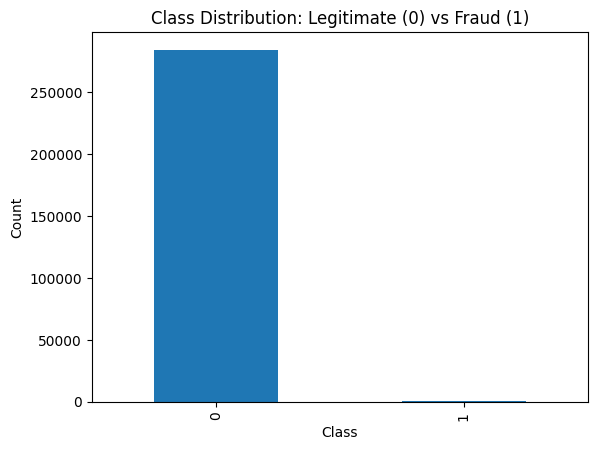

In [ ]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.title('Class Distribution: Legitimate (0) vs Fraud (1)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

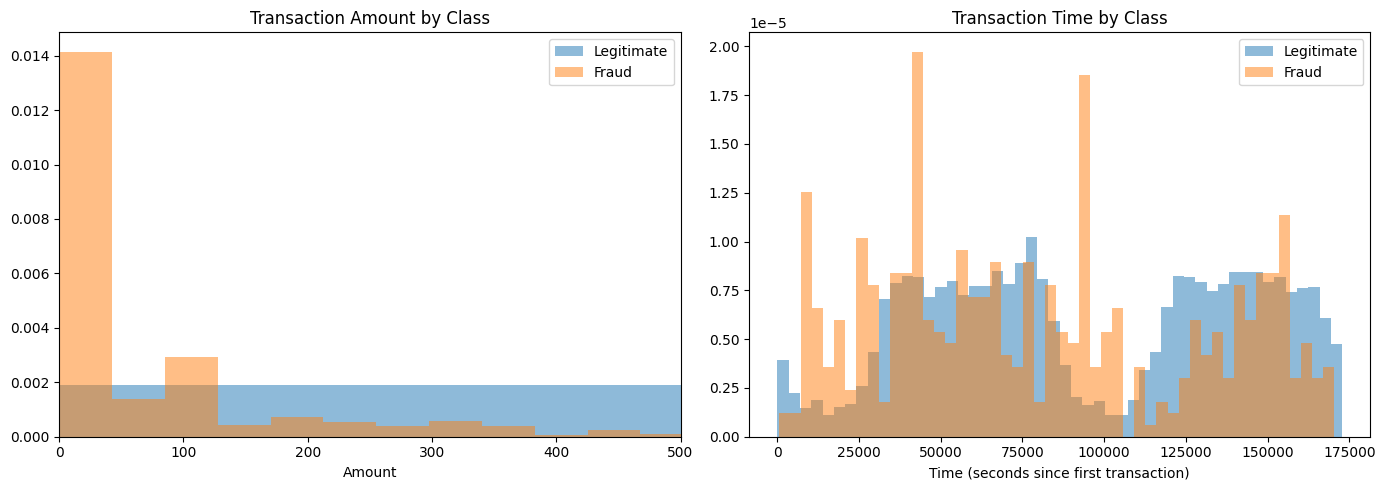

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.5, label='Legitimate', density=True)
axes[0].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.5, label='Fraud', density=True)
axes[0].set_xlim(0, 500)
axes[0].set_title('Transaction Amount by Class')
axes[0].set_xlabel('Amount')
axes[0].legend()


axes[1].hist(df[df['Class']==0]['Time'], bins=50, alpha=0.5, label='Legitimate', density=True)
axes[1].hist(df[df['Class']==1]['Time'], bins=50, alpha=0.5, label='Fraud', density=True)
axes[1].set_title('Transaction Time by Class')
axes[1].set_xlabel('Time (seconds since first transaction)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test_scaled[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

print("Setup complete:", X_train_scaled.shape, X_test_scaled.shape)

(227845, 30) (56962, 30)
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64
Setup complete: (227845, 30) (56962, 30)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression baseline
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Random Forest baseline
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Both models trained.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Both models trained.


In [ ]:
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_log))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.69      0.76        98

    accuracy                           1.00     56962
   macro avg       0.92      0.85      0.88     56962
weighted avg       1.00      1.00      1.00     56962

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
# Random Forest on SMOTE data
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test_scaled)

In [ ]:
# XGBoost on SMOTE data
!pip install -q xgboost
from xgboost import XGBClassifier

xgb_smote = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_smote.fit(X_train_smote, y_train_smote)
y_pred_xgb_smote = xgb_smote.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report

print("=== Random Forest + SMOTE ===")
print(classification_report(y_test, y_pred_rf_smote))

print("=== XGBoost + SMOTE ===")
print(classification_report(y_test, y_pred_xgb_smote))

=== Random Forest + SMOTE ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

=== XGBoost + SMOTE ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.24      0.89      0.38        98

    accuracy                           0.99     56962
   macro avg       0.62      0.94      0.69     56962
weighted avg       1.00      0.99      1.00     56962



In [ ]:
# Random Forest with class_weight='balanced' (no SMOTE)
rf_weighted = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_weighted.fit(X_train_scaled, y_train)
y_pred_rf_weighted = rf_weighted.predict(X_test_scaled)

# XGBoost with scale_pos_weight (no SMOTE)
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
xgb_weighted = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'
)
xgb_weighted.fit(X_train_scaled, y_train)
y_pred_xgb_weighted = xgb_weighted.predict(X_test_scaled)

print("=== Random Forest + Class Weighting ===")
print(classification_report(y_test, y_pred_rf_weighted))
print("=== XGBoost + Class Weighting ===")
print(classification_report(y_test, y_pred_xgb_weighted))

=== Random Forest + Class Weighting ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

=== XGBoost + Class Weighting ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.50      0.85      0.63        98

    accuracy                           1.00     56962
   macro avg       0.75      0.92      0.81     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
import shap

# SHAP for Random Forest + SMOTE
explainer_smote = shap.TreeExplainer(rf_smote)
# Use a sample of the test set for speed - explaining all 56,962 rows would be very slow
sample_idx = X_test_scaled.sample(n=500, random_state=42).index
X_sample = X_test_scaled.loc[sample_idx]

shap_values_smote = explainer_smote.shap_values(X_sample)

# SHAP for Random Forest + Class-Weight
explainer_weighted = shap.TreeExplainer(rf_weighted)
shap_values_weighted = explainer_weighted.shap_values(X_sample)

print("SHAP values calculated for both models.")

SHAP values calculated for both models.


In [ ]:
print(type(shap_values_smote))
if isinstance(shap_values_smote, list):
    print(len(shap_values_smote))

<class 'numpy.ndarray'>


In [ ]:
print(shap_values_smote.shape)

(500, 30, 2)


In [ ]:
# Extract fraud-class (index 1) SHAP values for both models
shap_smote_fraud = shap_values_smote[:, :, 1]
shap_weighted_fraud = shap_values_weighted[:, :, 1]

print(shap_smote_fraud.shape)
print(shap_weighted_fraud.shape)

(500, 30)
(500, 30)


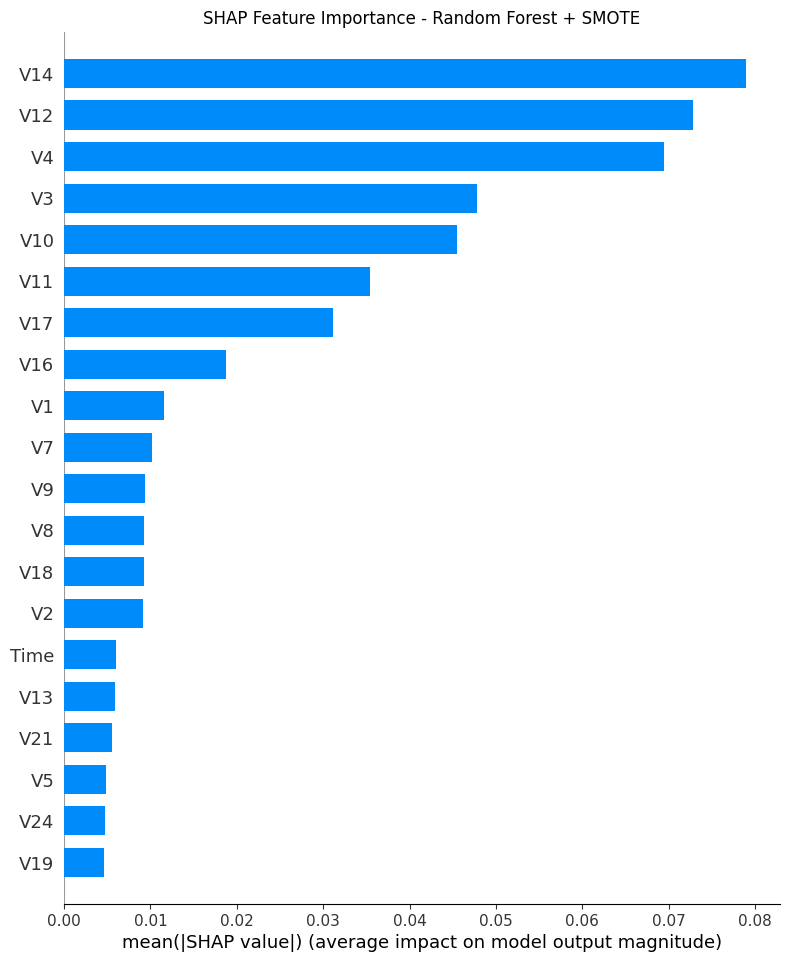

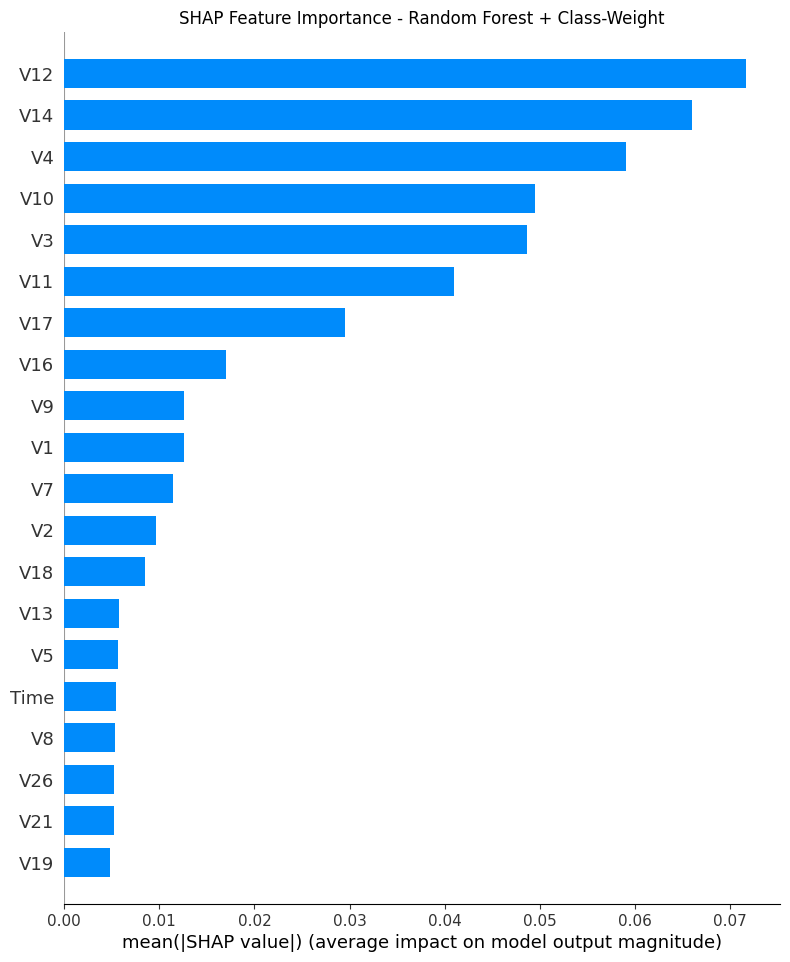

In [ ]:
shap.summary_plot(shap_smote_fraud, X_sample, plot_type="bar", show=False)
import matplotlib.pyplot as plt
plt.title("SHAP Feature Importance - Random Forest + SMOTE")
plt.show()

shap.summary_plot(shap_weighted_fraud, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance - Random Forest + Class-Weight")
plt.show()

In [ ]:
from scipy.stats import spearmanr
import numpy as np

# Mean absolute SHAP value per feature, for each method
mean_shap_smote = np.abs(shap_smote_fraud).mean(axis=0)
mean_shap_weighted = np.abs(shap_weighted_fraud).mean(axis=0)

# Spearman correlation between the two feature importance rankings
corr, p_value = spearmanr(mean_shap_smote, mean_shap_weighted)
print(f"Spearman correlation: {corr:.4f}, p-value: {p_value:.4f}")

Spearman correlation: 0.9809, p-value: 0.0000


In [31]:
# SHAP for XGBoost + SMOTE
explainer_xgb_smote = shap.TreeExplainer(xgb_smote)
shap_values_xgb_smote = explainer_xgb_smote.shap_values(X_sample)

# SHAP for XGBoost + Class-Weight
explainer_xgb_weighted = shap.TreeExplainer(xgb_weighted)
shap_values_xgb_weighted = explainer_xgb_weighted.shap_values(X_sample)

print(shap_values_xgb_smote.shape)

(500, 30)


In [33]:
shap_xgb_smote_fraud = shap_values_xgb_smote
shap_xgb_weighted_fraud = shap_values_xgb_weighted
print(shap_xgb_smote_fraud.shape, shap_xgb_weighted_fraud.shape)

(500, 30) (500, 30)


In [34]:
mean_shap_xgb_smote = np.abs(shap_xgb_smote_fraud).mean(axis=0)
mean_shap_xgb_weighted = np.abs(shap_xgb_weighted_fraud).mean(axis=0)

corr_xgb, p_value_xgb = spearmanr(mean_shap_xgb_smote, mean_shap_xgb_weighted)
print(f"XGBoost Spearman correlation: {corr_xgb:.4f}, p-value: {p_value_xgb:.4f}")

XGBoost Spearman correlation: 0.6925, p-value: 0.0000


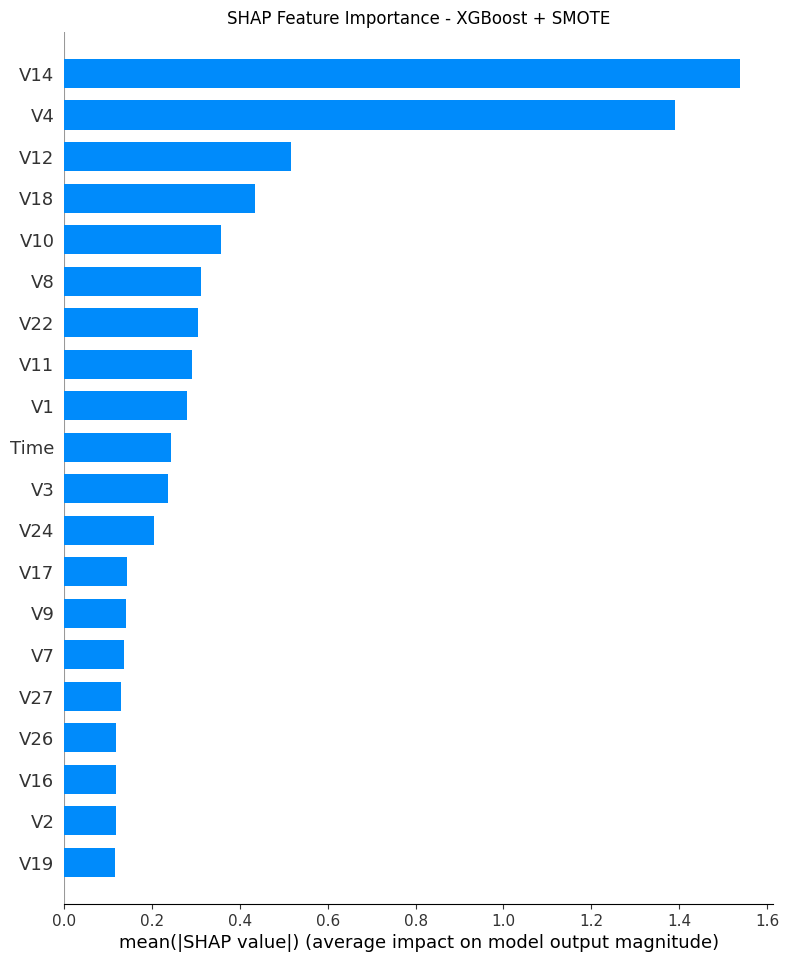

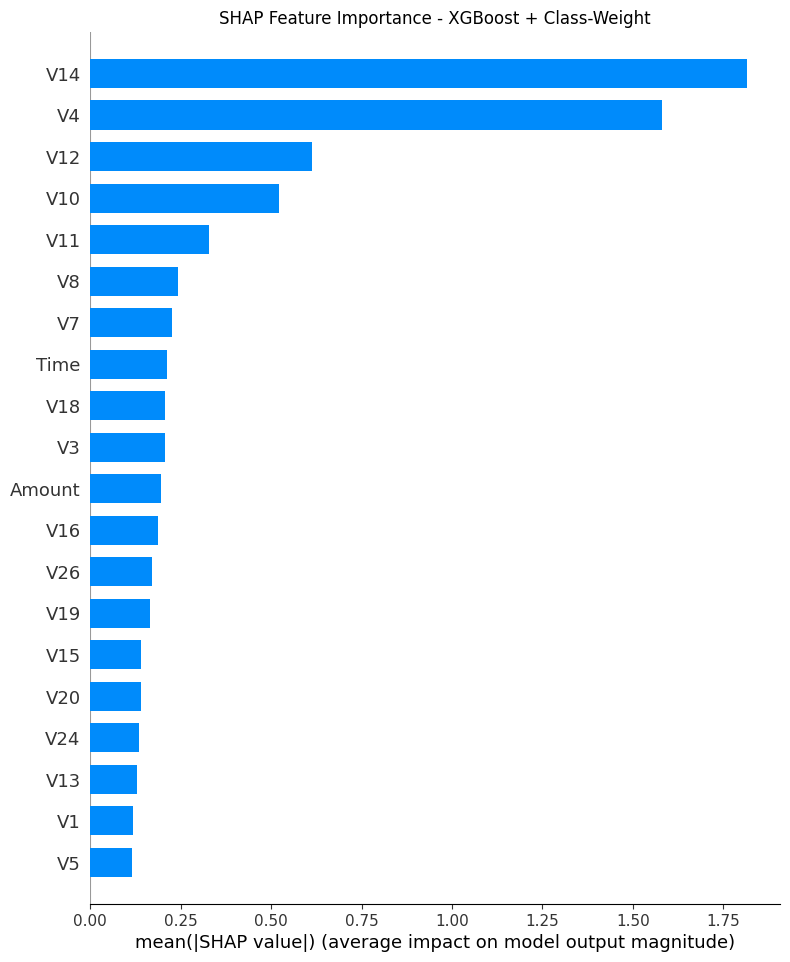

In [35]:
shap.summary_plot(shap_xgb_smote_fraud, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance - XGBoost + SMOTE")
plt.show()

shap.summary_plot(shap_xgb_weighted_fraud, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance - XGBoost + Class-Weight")
plt.show()

In [36]:
# Find actual fraud cases in your sample to explain
fraud_indices_in_sample = np.where(y_test.loc[sample_idx].values == 1)[0]
print(f"Number of actual fraud cases in sample: {len(fraud_indices_in_sample)}")
print(fraud_indices_in_sample[:5])  # show first few positions

Number of actual fraud cases in sample: 0
[]


In [37]:
# Get all actual fraud indices from the test set
fraud_test_idx = y_test[y_test == 1].index
legit_test_idx = y_test[y_test == 0].sample(n=200, random_state=42).index

# Combine: all fraud cases + a matching sample of legitimate ones
combined_idx = fraud_test_idx.union(legit_test_idx)
X_sample = X_test_scaled.loc[combined_idx]
y_sample = y_test.loc[combined_idx]

print(f"Fraud cases in new sample: {(y_sample==1).sum()}")
print(f"Legitimate cases in new sample: {(y_sample==0).sum()}")

Fraud cases in new sample: 98
Legitimate cases in new sample: 200


In [38]:
shap_values_smote = explainer_smote.shap_values(X_sample)
shap_values_weighted = explainer_weighted.shap_values(X_sample)

shap_smote_fraud = shap_values_smote[:, :, 1]
shap_weighted_fraud = shap_values_weighted[:, :, 1]

print(shap_smote_fraud.shape)

(298, 30)


Number of fraud cases: 98


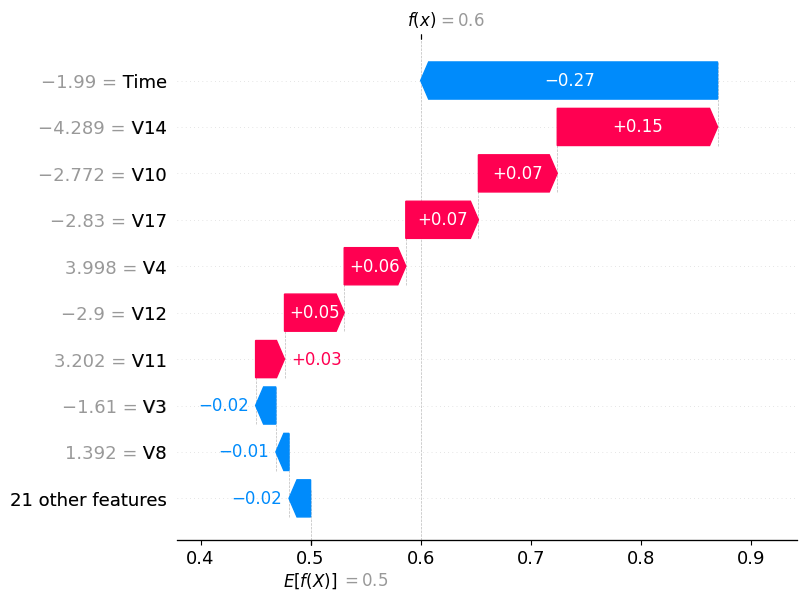

In [39]:
fraud_indices_in_sample = np.where(y_sample.values == 1)[0]
print(f"Number of fraud cases: {len(fraud_indices_in_sample)}")

idx_to_explain = fraud_indices_in_sample[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_smote_fraud[idx_to_explain],
        base_values=explainer_smote.expected_value[1],
        data=X_sample.iloc[idx_to_explain],
        feature_names=X_sample.columns.tolist()
    )
)